In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from modular_alignments.alignment_strengths import sigmoid, compound_sigmoid
from matplotlib import cm
from matplotlib.colors import Normalize

In [2]:
data = np.load("diffsky_sigmoidal_mu.npz", allow_pickle=True)

In [5]:
for key in data.keys():
    print(key)

ra
dec
halo_phi
aligned_phi
centrals
redshift
mu


In [11]:
data["halo_phi"]

array([2.70808904, 2.8074789 , 2.24572096, ..., 0.838519  , 2.56535259,
       2.09247131])

# Plots

In [13]:
mpl.rcParams["axes.titlesize"] = 20
mpl.rcParams["axes.labelsize"] = 18
mpl.rcParams["xtick.labelsize"] = 15
mpl.rcParams["ytick.labelsize"] = 15
mpl.rcParams["legend.fontsize"] = 20
mpl.rcParams["legend.frameon"] = False

## Sigmoids

redshfit params:
- x0: 2.0
- k: -1.0
- y_low: 0.6
- y_high: 1.0

log_sm params:
- x0: 6.0
- k:0.5
- y_low: 0
- y_high: redshift

In [67]:
dummy_z = np.linspace(0,3,100)
dummy_logsm = np.linspace(1,15,100)

redshift_params = {"x0":2.0, "k":-1.0, "y_low":0.6, "y_high":1.0}
log_mass_params =  {"x0":6.0, "k":0.5, "y_low":0.}

redshift_sigmoid = sigmoid(dummy_z, **redshift_params)
logsm_sigmoid = sigmoid(dummy_logsm, **log_mass_params)
multi_log_sm = []
N = 10
step_size = int( len(redshift_sigmoid)/N )
y_highs = np.array(redshift_sigmoid[::N])
z_pieces = np.array(dummy_z[::N])
for yh in y_highs:
    multi_log_sm.append( sigmoid(dummy_logsm, **log_mass_params, y_high=yh) )
mu = compound_sigmoid([dummy_z, dummy_logsm], [redshift_params, log_mass_params])

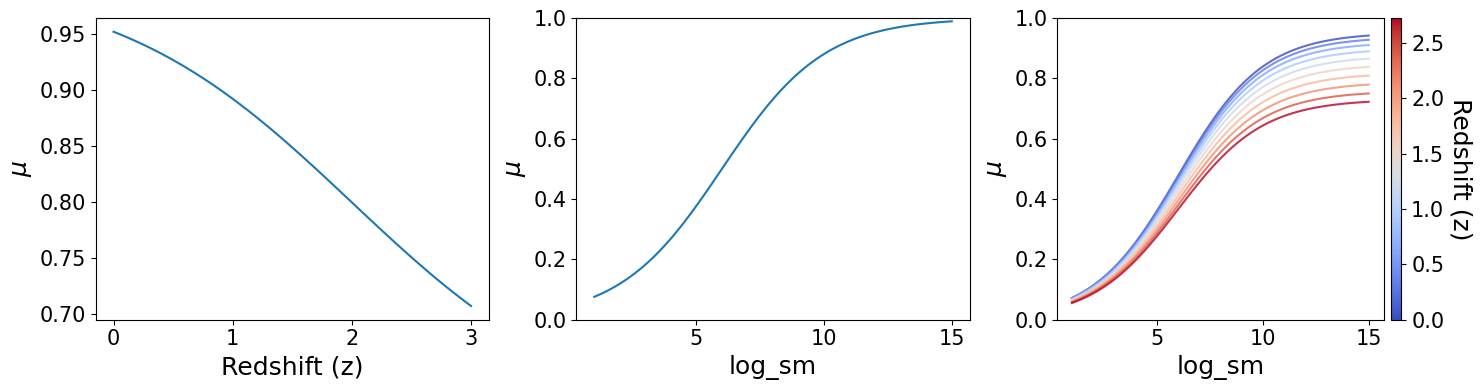

In [69]:
# Create figure with three panels
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: First basic sigmoid
x = np.linspace(0, 10, 100)
# Your sigmoid 1 generation here
axes[0].plot(dummy_z, redshift_sigmoid)
axes[0].set_xlabel('Redshift (z)')
axes[0].set_ylabel(r'$\mu$')
# axes[0].grid(True, alpha=0.3)

# Panel 2: Second basic sigmoid
# Your sigmoid 2 generation here
axes[1].plot(dummy_logsm, logsm_sigmoid)
axes[1].set_xlabel('log_sm')
axes[1].set_ylabel(r'$\mu$')
axes[1].set_ylim(0,1)
# axes[1].grid(True, alpha=0.3)

# Panel 3: Compound sigmoids with coolwarm gradient
# Example of how to use coolwarm colormap
n_curves = 10  # number of compound sigmoids
colors = cm.coolwarm(np.linspace(0, 1, n_curves))

for i in range(n_curves):
    # Your compound sigmoid generation here
    axes[2].plot(dummy_logsm, multi_log_sm[i], color=colors[i], alpha=0.8)

axes[2].set_xlabel('log_sm')
axes[2].set_ylabel(r'$\mu$')
axes[2].set_ylim(0,1)
# axes[2].grid(True, alpha=0.3)

# Define your high and low values
low_value = min(z_pieces)   # Replace with your actual low value
high_value = max(z_pieces)  # Replace with your actual high value

# Create normalization and colormap
norm = Normalize(vmin=low_value, vmax=high_value)
sm = cm.ScalarMappable(cmap=cm.coolwarm, norm=norm)
sm.set_array([])  # Required for older matplotlib versions

# Add colorbar to the right of the rightmost panel only
cbar = fig.colorbar(sm, ax=axes[2], orientation='vertical', pad=0.02, aspect=30)
cbar.set_label('Redshift (z)', rotation=270, labelpad=20)

plt.tight_layout()

plt.savefig("three_panel_sigmoid.pdf", dpi=300)
plt.show()

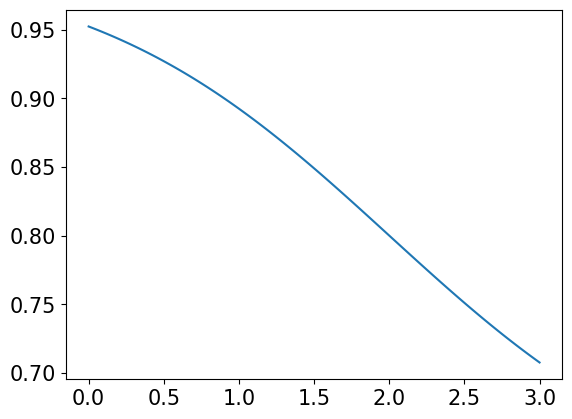

In [27]:
plt.plot(dummy_z, redshift_sigmoid)

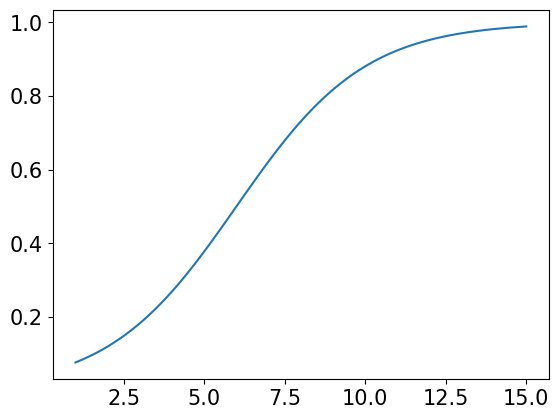

In [33]:
plt.plot(dummy_logsm, logsm_sigmoid)

## Mu histogram
From sigmoidal mu

redshift -> log_sm

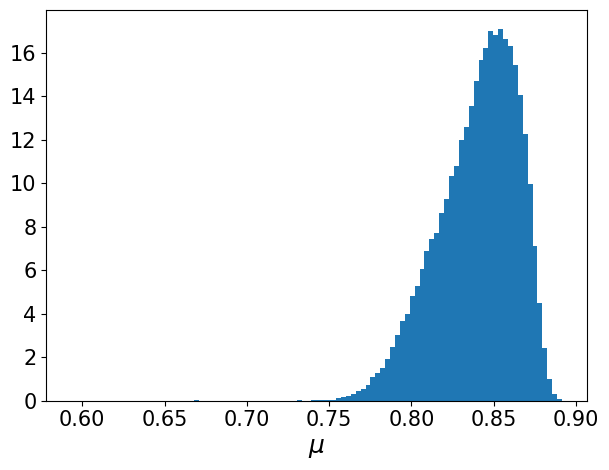

In [72]:
plt.hist(data["mu"], bins=100, density=True);
plt.xlabel(r"$\mu$")
plt.tight_layout()
plt.savefig("mu_histogram.pdf", dpi=300)

## Mu Scatterplot

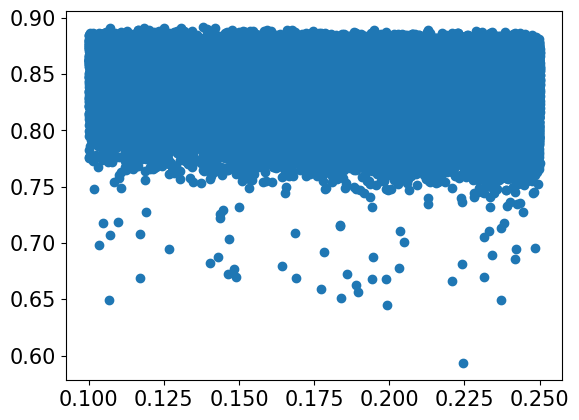

In [71]:
plt.scatter(data["redshift"], data["mu"])

(array([ 802.,  816.,  792.,  765., 1007.,  971.,  945.,  916., 1048.,
        1029., 1045., 1119., 1157., 1299., 1438., 1520., 1781., 1617.,
        1820., 1935., 1810., 2062., 1946., 1939., 2018., 1860., 1944.,
        2003., 2122., 2222., 2096., 2504., 2288., 2346., 2596., 2656.,
        2512., 2621., 2742., 2524., 2835., 2959., 2879., 2772., 3191.,
        3078., 3339., 3348., 3351., 3615.]),
 array([0.10000169, 0.10300161, 0.10600153, 0.10900145, 0.11200137,
        0.11500128, 0.1180012 , 0.12100112, 0.12400104, 0.12700096,
        0.13000087, 0.13300079, 0.13600071, 0.13900064, 0.14200056,
        0.14500047, 0.14800039, 0.15100031, 0.15400022, 0.15700014,
        0.16000006, 0.16299999, 0.1659999 , 0.16899982, 0.17199974,
        0.17499965, 0.17799957, 0.18099949, 0.1839994 , 0.18699932,
        0.18999925, 0.19299917, 0.19599909, 0.198999  , 0.20199892,
        0.20499884, 0.20799875, 0.21099867, 0.2139986 , 0.21699852,
        0.21999843, 0.22299835, 0.22599827, 0.22899818, 

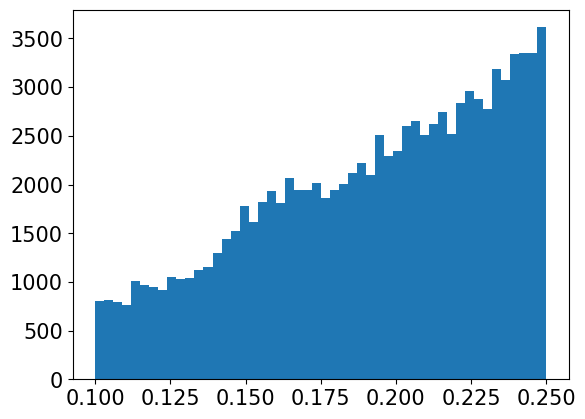

In [70]:
plt.hist(data["redshift"], bins=50)